
# K-Means Clustering — Derivation, Clarification, Matrix Form, and Elegant Implementation

**The central idea of K-Means is unusually clean**:

$$ \boxed{ \text{Represent }N\text{ observations using }K\text{ prototype vectors while minimizing squared reconstruction error.} } $$

Everything in the algorithm follows from that single optimization problem.

K-Means is best understood not as "repeatedly move some dots around," but as alternating optimization over two coupled unknowns:

which centroid represents each observation;
where those centroids should be.

The classical K-Means criterion is the within-cluster sum of squared Euclidean distances. Pollard gives the equivalent population/statistical formulation and shows that cluster means arise necessarily from minimizing this criterion. Hartigan and Wong's classic algorithm is another foundational treatment of computational K-Means clustering.**bold text**


## 1. Setup and notation

We use the **row-observation convention**:

$$
X =
\begin{bmatrix}
x_1^T\\
x_2^T\\
\vdots\\
x_N^T
\end{bmatrix}
\in \mathbb{R}^{N\times D},
\qquad
x_i\in\mathbb{R}^{D}.
$$

Here:

- $N$: number of observations
- $D$: number of features
- $K$: number of clusters

A mathematical feature vector $x_i$ is treated as a column vector in $\mathbb R^D$, while $x_i^T$ is laid across row $i$ of the NumPy matrix $X$.

### Clarification checkpoint — row versus column convention

This distinction matters later.

Because observations are stored as **rows**,

$$
X:(N,D).
$$

Therefore

$$
Z^T X:
(K,N)(N,D)
=
(K,D)
$$

is valid and gives one row per cluster.

If instead observations were stored as columns,

$$
X_{\text{col}}\in\mathbb R^{D\times N},
$$

the corresponding cluster-sum operation would be $X_{\text{col}}Z$, not $Z^TX_{\text{col}}$.



## 2. The two unknowns: assignments and centroid locations

K-Means must infer **two coupled objects**.

### Assignment matrix

For each point $x_i$, define

$$
z_{ik}\in\{0,1\}
$$

with

$$
z_{ik}
=
\begin{cases}
1,&x_i\text{ is assigned to cluster }k,\\
0,&\text{otherwise}.
\end{cases}
$$

Collect the assignments into

$$
Z\in\{0,1\}^{N\times K}.
$$

Every row of $Z$ is one-hot:

$$
\boxed{
\sum_{k=1}^{K} z_{ik}=1
}
\qquad\forall i.
$$

### Centroid matrix

Each centroid is

$$
\mu_k\in\mathbb R^D.
$$

Collect the centroids as rows:

$$
M=
\begin{bmatrix}
\mu_1^T\\
\mu_2^T\\
\vdots\\
\mu_K^T
\end{bmatrix}
\in\mathbb R^{K\times D}.
$$


## 3. Objective function

K-Means minimizes the within-cluster sum of squared Euclidean distances:

$$
\boxed{
J(Z,M)
=
\sum_{i=1}^{N}
\sum_{k=1}^{K}
z_{ik}
\|x_i-\mu_k\|_2^2
}
$$

subject to

$$
z_{ik}\in\{0,1\},
\qquad
\sum_{k=1}^{K}z_{ik}=1.
$$

### What does $z_{ik}$ do inside the sum?

For a fixed row $i$, exactly one assignment is 1.

So

$$
\sum_{k=1}^{K}
z_{ik}\|x_i-\mu_k\|^2
$$

contains $K$ candidate distances but the one-hot vector acts as a **switch**.

Once an assignment has been chosen, all non-selected distances are multiplied by zero.

Thus the objective can be read as

$$
\boxed{
\text{total squared distance from every point to the centroid currently assigned to it}
}
$$



## 4. Equivalent objective: eliminate $Z$ by embedding its optimal choice

For a **fixed set of centroids**, the best possible assignment for $x_i$ is the nearest centroid:

$$
\min_k\|x_i-\mu_k\|^2.
$$

Therefore the explicit constrained problem

$$
\min_{Z,M}
\sum_{i=1}^{N}
\sum_{k=1}^{K}
z_{ik}\|x_i-\mu_k\|^2
$$

is equivalently expressible as

$$
\boxed{
\min_{\mu_1,\ldots,\mu_K}
\sum_{i=1}^{N}
\min_{k}
\|x_i-\mu_k\|^2
}
$$

because the inner minimum already incorporates the optimal one-hot choice for the row $z_i$.


## 5. Alternating minimization

Joint optimization over $Z$ and $M$ is difficult.

But if one is fixed, the other becomes simple.

A common implementation starts from initial centroids $M^{(0)}$:

$$
\boxed{
M^{(0)}
\rightarrow
Z^{(1)}
\rightarrow
M^{(1)}
\rightarrow
Z^{(2)}
\rightarrow
M^{(2)}
\rightarrow\cdots
}
$$

where

$$
Z^{(t+1)}
=
\arg\min_Z
J(Z,M^{(t)})
$$

and

$$
M^{(t+1)}
=
\arg\min_M
J(Z^{(t+1)},M).
$$

### Clarification checkpoint — what is fixed and what changes?

| Step | Fixed | Optimized |
|---|---|---|
| Assignment | $M$ | $Z$ |
| Centroid update | $Z$ | $M$ |

If we instead initialize assignments first, the timeline can begin with $Z^{(0)}\rightarrow M^{(1)}$. The algorithmic principle is identical; only the initial state differs.



# 6. Assignment step: fixed centroids, optimize $Z$

Suppose

$$
\mu_1,\ldots,\mu_K
$$

are fixed.

For one observation $x_i$,

$$
J_i
=
\sum_{k=1}^{K}
z_{ik}\|x_i-\mu_k\|^2.
$$

The row $z_i$ must contain exactly one 1.

The candidate costs are therefore

$$
d_{i1}^2,\ldots,d_{iK}^2
$$

where

$$
d_{ik}^2=\|x_i-\mu_k\|^2.
$$

To minimize $J_i$, put the 1 at the smallest candidate:

$$
\boxed{
c_i
=
\arg\min_k
\|x_i-\mu_k\|_2^2
}
$$

and equivalently

$$
\boxed{
z_{ik}
=
\mathbf 1
\left[
k=c_i
\right].
}
$$

### Clarification checkpoint — “but doesn't $z_{ik}$ already filter the distance?”

Only **after we choose it**.

At the beginning of the assignment step, $M$ is fixed but $z_i$ is still unknown.

The logical order is:

$$
\text{compare all }K\text{ distances}
\rightarrow
\arg\min
\rightarrow
\text{construct the one-hot row }z_i
\rightarrow
z_i\text{ now acts as a filter}.
$$

So the minimum is not applied *after* filtering; it is the rule used to **choose the filter**.



## 6.1 One point versus the whole dataset

The derivation isolates one $x_i$ because its assignment can be solved independently.

But the complete assignment step performs the same optimization for

$$
i=1,\ldots,N.
$$

Since one point's assignment does not constrain another point's assignment,

$$
\min_Z J(Z,M)
=
\sum_{i=1}^{N}
\min_{z_i}
J_i(z_i,M).
$$

Thus K-Means solves $N$ independent nearest-centroid problems simultaneously.

### Matrix viewpoint

Define the squared-distance matrix

$$
D\in\mathbb R^{N\times K},
\qquad
D_{ik}=\|x_i-\mu_k\|^2.
$$

Then every row is one observation and every column is one centroid.

The assignment labels are simply

$$
\boxed{
c = \operatorname{argmin}_{\text{columns}}D.
}
$$



## 6.2 Pairwise squared distances in matrix form

Use

$$
\|x_i-\mu_k\|^2
=
x_i^Tx_i
+
\mu_k^T\mu_k
-
2x_i^T\mu_k.
$$

Define the row-norm vectors

$$
a_i=\|x_i\|^2,
\qquad
b_k=\|\mu_k\|^2.
$$

Then the complete distance matrix is

$$
\boxed{
D
=
a\mathbf 1_K^T
+
\mathbf 1_Nb^T
-
2XM^T.
}
$$

Dimensions:

$$
a\mathbf 1_K^T:(N,1)(1,K)\rightarrow(N,K),
$$

$$
XM^T:(N,D)(D,K)\rightarrow(N,K).
$$

This single matrix expression computes all $NK$ squared distances.




### The Core Algebraic Identity

As your text noted, the squared Euclidean distance between a single point $x_{i}$ and a single centroid $\mu _{k}$ expands like a standard quadratic polynomial:

$$ \|x_{i}-\mu _{k}\|{}_{2}^{2}=\|x_{i}\|{}_{2}^{2}+\|\mu _{k}\|{}_{2}^{2}-2x_{i}^{T}\mu _{k} $$

The matrix formula is simply trying to compute this exact three-term scalar equation for every possible pair of $i$ and $k$ simultaneously.

Let's use our running example: 3 data points ($N=3$) and 2 clusters ($K=2$).


**Part 1: $\mathbf{a1}_{K}^{T}$ (Spreading the Point Norms)**

Vector $\mathbf{a}$ contains the squared lengths of our 3 data points. It is a column vector of size $(3 \times 1)$:

$$ \mathbf{a}=\left[
\begin{matrix}
\|x_{1}\|{}_{2}^{2}\\
\|x_{2}\|{}_{2}^{2}\\
\|x_{3}\|{}_{2}^{2}
\end{matrix}
\right] $$

Vector $\mathbf{1}_{K}^{T}$ is a row vector of all ones of size $(1 \times 2)$:

$$ \mathbf{1}_{K}^{T}=\left[
\begin{matrix}
1&1
\end{matrix}
\right] $$

When you multiply a $(3 \times 1)$ by a $(1 \times 2)$, you get a $(3 \times 2)$ matrix. It takes the column $\mathbf{a}$ and copies it sideways across $K$ columns:

$$ \mathbf{a1}_{K}^{T}=\left[
\begin{matrix}
\|x_{1}\|{}_{2}^{2}\\
\|x_{2}\|{}_{2}^{2}\\
\|x_{3}\|{}_{2}^{2}
\end{matrix}
\right]\left[
\begin{matrix}
1&1
\end{matrix}
\right]=\left[
\begin{matrix}
\|x_{1}\|{}_{2}^{2}&\|x_{1}\|{}_{2}^{2}\\
\|x_{2}\|{}_{2}^{2}&\|x_{2}\|{}_{2}^{2}\\
\|x_{3}\|{}_{2}^{2}&\|x_{3}\|{}_{2}^{2}
\end{matrix}
\right] $$

Notice: Row $i$ now contains the squared length of point $x_{i}$, perfectly ready for any cluster it might meet.

**Part 2: $\mathbf{1}_N\mathbf{b}^T$ (Spreading the Centroid Norms)**

Vector $\mathbf{b}$ contains the squared lengths of our 2 centroids. Stated as a column vector, it is $(2 \times 1)$, so its transpose $\mathbf{b}^{T}$ is a row vector of size $(1 \times 2)$:

$$ \mathbf{b}^{T}=\left[
\begin{matrix}
\|\mu _{1}\|{}_{2}^{2}&\|\mu _{2}\|{}_{2}^{2}
\end{matrix}
\right] $$

Vector $\mathbf{1}_{N}$ is a column vector of all ones of size $(3 \times 1)$:

$$ \mathbf{1}_{N}=\left[
\begin{matrix}
1\\
1\\
1
\end{matrix}
\right] $$

When you multiply a $(3 \times 1)$ by a $(1 \times 2)$, you get another $(3 \times 2)$ matrix. This time, it takes the row vector and copies it downwards across $N$ rows:

$$ \mathbf{1}_{N}\mathbf{b}^{T}=\left[
\begin{matrix}
1\\
1\\
1
\end{matrix}
\right]\left[
\begin{matrix}
\|\mu _{1}\|{}_{2}^{2}&\|\mu _{2}\|{}_{2}^{2}
\end{matrix}
\right]=\left[
\begin{matrix}
\|\mu _{1}\|{}_{2}^{2}&\|\mu _{2}\|{}_{2}^{2}\\
\|\mu _{1}\|{}_{2}^{2}&\|\mu _{2}\|{}_{2}^{2}\\
\|\mu _{1}\|{}_{2}^{2}&\|\mu _{2}\|{}_{2}^{2}
\end{matrix}
\right] $$

Notice: Column $k$ now contains the squared length of centroid $\mu _{k}$, perfectly ready for any data point it might meet.

Part 3: $-2\mathbf{XM}^T$ (The Cross Terms)

This is where the actual data features interact. We multiply the data matrix $\mathbf{X}$ $(3 \times D)$ by the transposed centroid matrix $\mathbf{M}^{T}$ $(D \times 2)$.

The resulting matrix is size $(3 \times 2)$, where every individual cell $(i, k)$ is the dot product of point $i$ and centroid $k$:

$$ -2\mathbf{XM}^{T}=\left[
\begin{matrix}
-2x_{1}^{T}\mu _{1}&-2x_{1}^{T}\mu _{2}\\
-2x_{2}^{T}\mu _{1}&-2x_{2}^{T}\mu _{2}\\
-2x_{3}^{T}\mu _{1}&-2x_{3}^{T}\mu _{2}
\end{matrix}
\right] $$

### The Grand Total

Because all three parts have been stretched into the exact same shape ($(3 \times 2)$ matrices), we can simply add and subtract them element-by-element:

$$ \mathbf{D}=\left[
\begin{matrix}
(\Vert x_{1}\Vert{}_{2}^{2}+\Vert \mu _{1}\Vert{}_{2}^{2}-2x_{1}^{T}\mu _{1})&(\Vert x_{1}\Vert{}_{2}^{2}+\Vert \mu _{2}\Vert{}_{2}^{2}-2x_{1}^{T}\mu _{2})\\
(\Vert x_{2}\Vert{}_{2}^{2}+\Vert \mu _{1}\Vert{}_{2}^{2}-2x_{2}^{T}\mu _{1})&(\Vert x_{2}\Vert{}_{2}^{2}+\Vert \mu _{2}\Vert{}_{2}^{2}-2x_{2}^{T}\mu _{2})\\
(\Vert x_{3}\Vert{}_{2}^{2}+\Vert \mu _{1}\Vert{}_{2}^{2}-2x_{3}^{T}\mu _{1})&(\Vert x_{3}\Vert{}_{2}^{2}+\Vert \mu _{2}\Vert{}_{2}^{2}-2x_{3}^{T}\mu _{2})
\end{matrix}
\right] $$

Every single slot $(i, k)$ in this matrix now perfectly contains the scalar squared distance $\Vert x_i - \mu_k\Vert{}_2^2$.


# 7. Centroid update: fixed $Z$, optimize $M$

Now the assignments are fixed.

Consider **one fixed cluster index $k$**.

Its contribution is

$$
J_k(\mu_k)
=
\sum_{i=1}^{N}
z_{ik}
\|x_i-\mu_k\|^2.
$$

We seek

$$
\boxed{
\mu_k^*
=
\arg\min_{\mu_k}
J_k(\mu_k).
}
$$

### Clarification checkpoint — if $k$ is fixed, why is $\mu_k$ changing?

Because $k$ is only an **index/label**.

“Consider cluster $k$” means:

> choose one specific cluster, say cluster 2, and keep its membership fixed.

But its location vector

$$
\mu_k\in\mathbb R^D
$$

is still the variable we are optimizing.

So:

$$
k=\text{fixed label},
\qquad
\mu_k=\text{variable coordinate vector}.
$$



## 7.1 Rigorous centroid derivation

Start with

$$
J_k(\mu_k)
=
\sum_i z_{ik}
\|x_i-\mu_k\|^2.
$$

Expand the squared norm:

$$
\|x_i-\mu_k\|^2
=
(x_i-\mu_k)^T(x_i-\mu_k)
$$

$$
=
x_i^Tx_i
-
2x_i^T\mu_k
+
\mu_k^T\mu_k.
$$

Therefore

$$
J_k
=
\sum_i
z_{ik}
\left(
x_i^Tx_i
-
2x_i^T\mu_k
+
\mu_k^T\mu_k
\right).
$$

Differentiate with respect to $\mu_k$.

Because $x_i$ is fixed,

$$
\nabla_{\mu_k}(x_i^Tx_i)=0.
$$

Because $x_i^T\mu_k$ is linear in $\mu_k$,

$$
\nabla_{\mu_k}(-2x_i^T\mu_k)
=
-2x_i.
$$

And

$$
\nabla_{\mu_k}(\mu_k^T\mu_k)
=
2\mu_k.
$$

Hence

$$
\nabla_{\mu_k}J_k
=
\sum_i
z_{ik}
(-2x_i+2\mu_k)
$$

$$
=
2\sum_i
z_{ik}
(\mu_k-x_i).
$$

At an optimum,

$$
\nabla_{\mu_k}J_k=0.
$$

Therefore

$$
\sum_i z_{ik}(\mu_k-x_i)=0.
$$

Expand:

$$
\sum_i z_{ik}\mu_k
-
\sum_i z_{ik}x_i
=
0.
$$

Since $\mu_k$ does not depend on $i$,

$$
\mu_k
\sum_i z_{ik}
=
\sum_i z_{ik}x_i.
$$

Therefore

$$
\boxed{
\mu_k
=
\frac{
\sum_i z_{ik}x_i
}{
\sum_i z_{ik}
}.
}
$$

Let

$$
N_k=\sum_i z_{ik}.
$$

Then

$$
\boxed{
\mu_k
=
\frac1{N_k}
\sum_{i:z_i=k}
x_i.
}
$$

### Didactic interpretation

- Numerator: vector sum of points assigned to cluster $k$.
- Denominator: number of points assigned to cluster $k$.
- Result: the centroid — the coordinate-wise arithmetic mean of that group.



## 7.2 Why this stationary point is actually the minimum

For a non-empty cluster,

$$
N_k>0.
$$

The Hessian is

$$
\nabla^2_{\mu_k}J_k
=
2N_k I_D.
$$

Since

$$
2N_k I_D \succ 0,
$$

$J_k(\mu_k)$ is strictly convex in $\mu_k$.

Therefore the stationary point derived above is the **unique minimizer** for that fixed cluster assignment.



# 8. Matrix form of the centroid update

The scalar/vector update was

$$
\mu_k
=
\frac{
\sum_i z_{ik}x_i
}{
\sum_i z_{ik}
}.
$$

We now compute all $K$ centroids simultaneously.

Recall

$$
Z\in\{0,1\}^{N\times K},
\qquad
X\in\mathbb R^{N\times D}.
$$

Then

$$
Z^TX
$$

has dimensions

$$
(K,N)(N,D)
=
(K,D).
$$

Its $k$-th row is

$$
\sum_i z_{ik}x_i^T,
$$

the coordinate sum of the points assigned to cluster $k$.

Next,

$$
n
=
Z^T\mathbf 1_N
\in\mathbb R^K
$$

contains the cluster counts:

$$
n_k=\sum_i z_{ik}=N_k.
$$

Put the reciprocal counts on the diagonal:

$$
\operatorname{diag}(n)^{-1}
=
\operatorname{diag}
\left(
\frac1{N_1},\ldots,\frac1{N_K}
\right).
$$

Left multiplication divides each row of $Z^TX$ by its corresponding cluster count:

$$
\boxed{
M
=
\operatorname{diag}(Z^T\mathbf 1_N)^{-1}
Z^TX.
}
$$

This is the complete centroid update in one matrix equation.

> Assumption: every cluster is non-empty, so all $N_k>0$.


### Concrete Numerical Example: $Z^TX$

To see exactly what the matrix multiplication $Z^{T}X$ does, let's build a concrete numerical example using 3 data points ($N=3$) in a 2D space ($D=2$), split into 2 clusters ($K=2$).

#### 1. Define the Matrices

Let’s use the same 3 data points we looked at earlier:

*   $x_1 = (1, 2)$
*   $x_2 = (2, 3)$
*   $x_3 = (11, 12)$

We pack these rows into our data matrix $X$ (size $(3 \times 2)$):

$$ X=\left[
\begin{matrix}
1&2\\
2&3\\
11&12
\end{matrix}
\right] $$

Now, let's assign $x_{1}$ and $x_{2}$ to Cluster 1, and $x_{3}$ to Cluster 2. We pack these one-hot assignments into rows of our matrix $Z$ (size $(3 \times 2)$):

$$ Z=\left[
\begin{matrix}
1&0\\
1&0\\
0&1
\end{matrix}
\right] $$

#### 2. Compute the Transpose $Z^{T}$

To perform the multiplication, we flip $Z$ on its side to get $Z^{T}$ (size $(2 \times 3)$):

$$ Z^{T}=\left[
\begin{matrix}
1&1&0\\
0&0&1
\end{matrix}
\right] $$

Notice what the rows of $Z^{T}$ represent:

*   Row 1 acts as a mask/filter for Cluster 1 (picking out points 1 and 2).
*   Row 2 acts as a mask/filter for Cluster 2 (picking out point 3).

#### 3. Perform the Multiplication $Z^{T}X$

Now we multiply $Z^{T}$ (size $(2 \times 3)$) by $X$ (size $(3 \times 2)$). The resulting matrix will be of size $(2 \times 2)$:

$$ Z^{T}X=\left[
\begin{matrix}
1&1&0\\
0&0&1
\end{matrix}
\right]\left[
\begin{matrix}
1&2\\
2&3\\
11&12
\end{matrix}
\right] $$

Let's compute the rows of the output matrix one by one using standard matrix multiplication (row $\times$ column):

**Row 1 (Cluster 1 sum):**

*   Column 1: $(1 \times 1) + (1 \times 2) + (0 \times 11) = 1 + 2 + 0 = \mathbf{3}$
*   Column 2: $(1 \times 2) + (1 \times 3) + (0 \times 12) = 2 + 3 + 0 = \mathbf{5}$

Result for Row 1: $\left[
\begin{matrix}
3&5
\end{matrix}
\right]$ (which is exactly $x_1 + x_2$)

**Row 2 (Cluster 2 sum):**

*   Column 1: $(0 \times 1) + (0 \times 2) + (1 \times 11) = 0 + 0 + 11 = \mathbf{11}$
*   Column 2: $(0 \times 2) + (0 \times 3) + (1 \times 12) = 0 + 0 + 12 = \mathbf{12}$

Result for Row 2: $\left[
\begin{matrix}
11&12
\end{matrix}
\right]$ (which is exactly $x_{3}$)

#### The Final Result

$$ Z^{T}X=\left[
\begin{matrix}
3&5\\
11&12
\end{matrix}
\right] $$

#### What did $Z^{T}X$ just achieve?

The matrix operation $Z^{T}X$ simultaneously sums up the coordinates of the data points within each cluster.

*   Row 1 of the output is the vector sum of all points belonging to Cluster 1.
*   Row 2 of the output is the vector sum of all points belonging to Cluster 2.

This gives you the exact numerator needed for the centroid update formula across all clusters at the same time.

#### 1. The Denominator Vector: $Z^T \mathbf{1}_N$

The notation $\mathbf{1}_{N}$ represents a column vector of all ones of size $N \times 1$.

When you multiply $Z^{T}$ ($K \times N$) by $\mathbf{1}_{N}$, it acts as a row-sum counter:

$$ Z^{T}\mathbf{1}_{N}=\left[
\begin{matrix}
1&1&0\\
0&0&1
\end{matrix}
\right]\left[
\begin{matrix}
1\\
1\\
1
\end{matrix}
\right]=\left[
\begin{matrix}
1+1+0\\
0+0+1
\end{matrix}
\right]=\left[
\begin{matrix}
2\\
1
\end{matrix}
\right]=\left[
\begin{matrix}
N_{1}\\
N_{2}
\end{matrix}
\right] $$

This leaves you with a column vector containing the counts $[N_1, N_2, \dots, N_K]^T$ for each cluster.

#### 2. The Scaling Matrix: $\operatorname{diag}(Z^T\mathbf{1}_N)^{-1}$

To turn those counts into denominators for division, the formula uses two operations:

*   $\operatorname{diag}(\cdot)$: Takes that count vector and spreads it across the main diagonal of a blank matrix.
*   $(\cdot)^{-1}$ (Inverse): Inverts the diagonal elements, which turns every count value $N_{k}$ into its reciprocal $\frac{1}{N_{k}}$.

Using our counts $[2, 1]^T$, this creates:

$$ \mathrm{diag}(Z^{T}\mathbf{1}_{N})^{-1}=\left[
\begin{matrix}
2&0\\
0&1
\end{matrix}
\right]^{-1}=\left[
\begin{matrix}
\frac{1}{2}&0\\
0&\frac{1}{1}
\end{matrix}
\right] $$

#### 3. The Grand Finale: Putting It Together

Now, multiplying this diagonal scaling matrix by our numerator matrix $Z^{T}X$ performs the row-by-row division perfectly:

$$ M=\left[
\begin{matrix}
\frac{1}{2}&0\\
0&\frac{1}{1}
\end{matrix}
\right]\left[
\begin{matrix}
3&5\\
11&12
\end{matrix}
\right]=\left[
\begin{matrix}
\frac{3}{2}&\frac{5}{2}\\
\frac{11}{1}&\frac{12}{1}
\end{matrix}
\right]=\left[
\begin{matrix}
1.5&2.5\\
11&12
\end{matrix}
\right] $$

Look at the rows of the final matrix $M$:

*   Row 1: $(1.5, 2.5)$ is the exact mathematical center of Cluster 1.
*   Row 2: $(11, 12)$ is the exact mathematical center of Cluster 2.


## 8.1 Concrete matrix example: $N=3,\;D=2,\;K=2$

Use

$$
X=
\begin{bmatrix}
4&6\\
6&8\\
10&3
\end{bmatrix}
$$

and assignments

$$
Z=
\begin{bmatrix}
1&0\\
1&0\\
0&1
\end{bmatrix}.
$$

Notice the dimensions:

$$
X:(3,2),
\qquad
Z:(3,2).
$$

This is an important dimensional correction: with 3 observations and 2 clusters, $Z$ must have **3 rows and 2 columns**.

Transpose the assignments:

$$
Z^T=
\begin{bmatrix}
1&1&0\\
0&0&1
\end{bmatrix}.
$$

Now

$$
Z^TX
=
\begin{bmatrix}
1&1&0\\
0&0&1
\end{bmatrix}
\begin{bmatrix}
4&6\\
6&8\\
10&3
\end{bmatrix}
=
\begin{bmatrix}
10&14\\
10&3
\end{bmatrix}.
$$

The first row is $x_1+x_2$; the second is $x_3$.

The counts are

$$
Z^T\mathbf 1_3
=
\begin{bmatrix}
2\\
1
\end{bmatrix}.
$$

Therefore

$$
M
=
\begin{bmatrix}
1/2&0\\
0&1
\end{bmatrix}
\begin{bmatrix}
10&14\\
10&3
\end{bmatrix}
=
\boxed{
\begin{bmatrix}
5&7\\
10&3
\end{bmatrix}
}.
$$

So the matrix expression reproduces the two centroid means simultaneously.


In [ ]:

import numpy as np

X_example = np.array([
    [4., 6.],
    [6., 8.],
    [10., 3.],
])

Z_example = np.array([
    [1., 0.],
    [1., 0.],
    [0., 1.],
])

cluster_sums = Z_example.T @ X_example
cluster_counts = Z_example.T @ np.ones(len(X_example))
M_example = np.diag(1 / cluster_counts) @ cluster_sums

print("Z^T X =")
print(cluster_sums)
print("\ncluster counts =", cluster_counts)
print("\nM =")
print(M_example)


Z^T X =
[[10. 14.]
 [10.  3.]]

cluster counts = [2. 1.]

M =
[[ 5.  7.]
 [10.  3.]]



# 9. Why each alternating step cannot increase the objective

Let the current state be $(Z^{(t)},M^{(t)})$.

### Assignment update

By definition,

$$
Z^{(t+1)}
=
\arg\min_Z
J(Z,M^{(t)}).
$$

Therefore

$$
J(Z^{(t+1)},M^{(t)})
\le
J(Z^{(t)},M^{(t)}).
$$

### Centroid update

Then

$$
M^{(t+1)}
=
\arg\min_M
J(Z^{(t+1)},M).
$$

Therefore

$$
J(Z^{(t+1)},M^{(t+1)})
\le
J(Z^{(t+1)},M^{(t)}).
$$

Combining the two,

$$
\boxed{
J^{(t+1)}
\le
J^{(t)}.
}
$$

### Important clarification

This proves **monotonic non-increase**, not global optimality.

K-Means can converge to different stable solutions from different initial centroids because the complete problem is non-convex/combinatorial.

So the correct conclusion is:

$$
\boxed{
\text{each Lloyd step improves or preserves the current cost}
}
$$

not

$$
\boxed{
\text{Lloyd's algorithm always reaches the global minimum}.
}
$$



# 10. Norvig-style executable mathematics

The implementation below deliberately favors:

- small functions,
- mathematical names,
- composition,
- matrix operations,
- minimal ceremony.

The central correspondence is:

$$
\boxed{
\text{equation}
\rightarrow
\text{small function}
\rightarrow
\text{composition}
}
$$

The four conceptual primitives are:

1. `sqdist(X, M)` — all $\|x_i-\mu_k\|^2$
2. `assign(X, M)` — construct $Z$
3. `means(X, Z)` — compute $M$ using the matrix formula
4. `distortion(X, Z, M)` — evaluate $J(Z,M)$


In [ ]:

def sqdist(X, M):
    """D[i, k] = ||x_i - mu_k||^2."""
    return (
        (X * X).sum(axis=1)[:, None]
        + (M * M).sum(axis=1)[None, :]
        - 2 * X @ M.T
    )


def assign(X, M):
    """One-hot nearest-centroid assignments Z."""
    labels = sqdist(X, M).argmin(axis=1)
    return np.eye(len(M), dtype=int)[labels]


def means(X, Z):
    """All centroid means: M = diag(Z^T 1)^(-1) Z^T X."""
    counts = Z.T @ np.ones(len(X))
    if np.any(counts == 0):
        raise ValueError("K-Means produced an empty cluster.")
    return np.diag(1 / counts) @ Z.T @ X


def distortion(X, Z, M):
    """J(Z, M) = sum_ik z_ik ||x_i - mu_k||^2."""
    return np.sum(Z * sqdist(X, M))


def lloyd_step(X, M):
    """One complete assignment/update step."""
    Z = assign(X, M)
    return Z, means(X, Z)


def kmeans(X, k, *, seed=0, max_iter=100):
    """Lloyd's K-Means algorithm."""
    rng = np.random.default_rng(seed)
    M = X[rng.choice(len(X), k, replace=False)].copy()

    previous_Z = None
    history = []

    for _ in range(max_iter):
        Z, M = lloyd_step(X, M)
        history.append(distortion(X, Z, M))

        if previous_Z is not None and np.array_equal(Z, previous_Z):
            break

        previous_Z = Z.copy()

    return M, Z, np.asarray(history)



## 10.1 Code-to-math alignment

### Distance matrix

```python
sqdist(X, M)
```

implements

$$
D
=
a\mathbf 1_K^T
+
\mathbf 1_Nb^T
-
2XM^T.
$$

Shapes:

$$
X:(N,D),\qquad M:(K,D),\qquad D:(N,K).
$$

### Assignment

```python
sqdist(X, M).argmin(axis=1)
```

implements

$$
c_i=\arg\min_k D_{ik}.
$$

Then

```python
np.eye(K)[labels]
```

turns those labels into the one-hot matrix

$$
Z:(N,K).
$$

### Centroid update

```python
np.diag(1 / counts) @ Z.T @ X
```

is almost a literal transcription of

$$
M
=
\operatorname{diag}(Z^T\mathbf 1_N)^{-1}
Z^TX.
$$

### Lloyd iteration

```python
Z = assign(X, M)
M = means(X, Z)
```

reads directly as:

$$
\boxed{
\text{assign to nearest centers}
\rightarrow
\text{replace centers by cluster means}.
}
$$



# 11. Driver: generate points, cluster them, visualize the result

We will create three synthetic 2-D groups using NumPy only, run our implementation, and plot the learned partition.


In [ ]:

import matplotlib.pyplot as plt

rng = np.random.default_rng(12)

true_centers = np.array([
    [-4., -2.],
    [ 0.,  4.],
    [ 5., -1.],
])

X = np.vstack([
    rng.normal(center, 0.75, size=(120, 2))
    for center in true_centers
])

M, Z, history = kmeans(X, k=3, seed=0)
labels = Z.argmax(axis=1)

print("Learned centroids:")
print(M)
print(f"\nIterations: {len(history)}")
print(f"Final distortion: {history[-1]:.3f}")


Learned centroids:
[[-3.97268491 -2.00651271]
 [-0.04129587  4.05725   ]
 [ 4.98926392 -0.9262719 ]]

Iterations: 3
Final distortion: 394.381


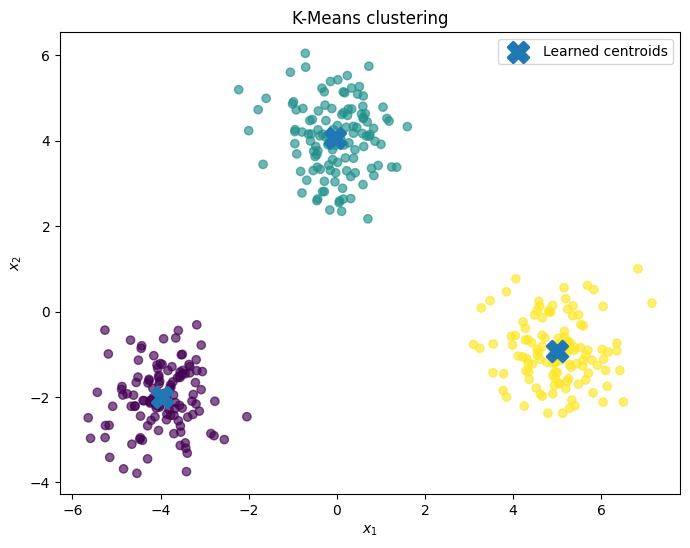

In [ ]:

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, alpha=0.65)
plt.scatter(
    M[:, 0],
    M[:, 1],
    marker="X",
    s=220,
    linewidths=2,
    label="Learned centroids",
)
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("K-Means clustering")
plt.legend()
plt.show()


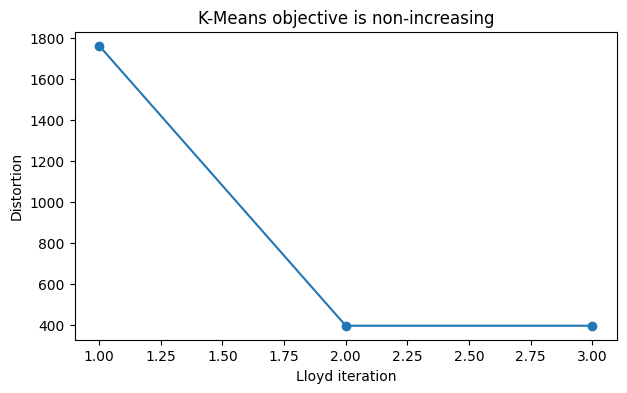

In [ ]:

plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(history) + 1), history, marker="o")
plt.xlabel("Lloyd iteration")
plt.ylabel("Distortion")
plt.title("K-Means objective is non-increasing")
plt.show()



# 12. Final compression

K-Means begins with one objective:

$$
\boxed{
J(Z,M)
=
\sum_{i,k}
z_{ik}\|x_i-\mu_k\|^2.
}
$$

Holding $M$ fixed gives the exact assignment solution:

$$
\boxed{
c_i=\arg\min_k\|x_i-\mu_k\|^2.
}
$$

Holding $Z$ fixed gives the exact centroid solution:

$$
\boxed{
\mu_k
=
\frac{\sum_i z_{ik}x_i}{\sum_i z_{ik}}.
}
$$

All centroids simultaneously:

$$
\boxed{
M
=
\operatorname{diag}(Z^T\mathbf 1_N)^{-1}
Z^TX.
}
$$

And Lloyd's algorithm is simply repeated composition:

$$
\boxed{
M
\rightarrow
Z
\rightarrow
M
\rightarrow
Z
\rightarrow\cdots
}
$$

with each step guaranteed not to increase $J$.

The implementation mirrors the derivation:

```python
Z = assign(X, M)
M = means(X, Z)
```

That is K-Means in its most compact form:

$$
\boxed{
\text{nearest representative}
\;\longleftrightarrow\;
\text{mean of represented points}.
}
$$


# 🔵 PyTorch: The Same Mathematics on a GPU

NumPy's standard ndarray execution model is CPU-based.

PyTorch provides essentially the same tensor and matrix vocabulary while allowing those operations to execute on a CUDA GPU.

The mathematics does not change.

Our squared-distance matrix remains

$$
\boxed{
D
=
a\mathbf 1_K^T
+
\mathbf 1_Nb^T
-
2XM^T
}
$$

with

$$
a_i=\|x_i\|^2,
\qquad
b_k=\|\mu_k\|^2.
$$

The crucial matrix multiplication

$$
XM^T
$$

is now executed by highly optimized GPU kernels.

Thus the transition is

$$
\text{NumPy arrays on CPU}
\rightarrow
\text{PyTorch tensors on CUDA},
$$

not a change in the underlying K-Means mathematics.

In [1]:
import torch
import torch.nn.functional as F


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
Device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [3]:
import numpy as np

# Recreate the same 3-cluster synthetic dataset
rng = np.random.default_rng(7)

X_np = np.vstack([
    rng.normal(loc=(-4.0, -2.0), scale=0.7, size=(120, 2)),
    rng.normal(loc=( 0.0,  4.0), scale=0.8, size=(120, 2)),
    rng.normal(loc=( 5.0, -1.0), scale=0.6, size=(120, 2)),
])

K = 3

# Common initialization for SciPy and PyTorch
rng_init = np.random.default_rng(0)

init_idx = rng_init.choice(
    len(X_np),
    size=K,
    replace=False,
)

M0 = X_np[init_idx].copy()

print("X_np shape:", X_np.shape)
print("K:", K)
print("Initial centroid indices:", init_idx)
print("M0 shape:", M0.shape)
print("\nM0:")
print(M0)

X_np shape: (360, 2)
K: 3
Initial centroid indices: [228 184 304]
M0 shape: (3, 2)

M0:
[[ 0.76677036  3.27498479]
 [ 0.6837114   4.56498805]
 [ 3.646991   -1.20092409]]


In [4]:



X_t = torch.as_tensor(
    X_np,
    dtype=torch.float32,
    device=device,
)

M0_t = torch.as_tensor(
    M0,
    dtype=torch.float32,
    device=device,
)

print("X :", X_t.shape, X_t.device)
print("M0:", M0_t.shape, M0_t.device)

X : torch.Size([360, 2]) cuda:0
M0: torch.Size([3, 2]) cuda:0


In [5]:
def sqdist_torch(X, M):
    """
    Pairwise squared Euclidean distances.

        D[i, k] = ||x_i - mu_k||^2

    Matrix identity:

        D = a 1^T + 1 b^T - 2 X M^T

    Shapes
    ------
    X : (N, D)
    M : (K, D)
    D : (N, K)
    """

    x2 = (X * X).sum(
        dim=1,
        keepdim=True,
    )

    m2 = (M * M).sum(
        dim=1,
    ).unsqueeze(0)

    D = x2 + m2 - 2 * X @ M.T

    # Floating-point cancellation can occasionally create
    # extremely small negative values such as -1e-7.
    return D.clamp_min(0)

In [6]:
def assign_torch(X, M):
    """
    Nearest-centroid assignment.

    Returns
    -------
    Z      : (N, K) one-hot matrix
    labels : (N,) cluster labels
    """

    labels = sqdist_torch(X, M).argmin(dim=1)

    Z = F.one_hot(
        labels,
        num_classes=len(M),
    ).to(X.dtype)

    return Z, labels

For fixed assignments $Z$, the centroid update is

$$
M
=
\operatorname{diag}
\left(
Z^T\mathbf1_N
\right)^{-1}
Z^TX.
$$

The matrix

$$
Z^TX
$$

contains the sum of the observations assigned to each cluster.

Meanwhile,

$$
Z^T\mathbf1_N
$$

contains the number of observations in each cluster.

Instead of explicitly constructing the diagonal matrix, we divide each row of $Z^TX$ by its corresponding cluster count.

This is algebraically identical but computationally cleaner.

In [7]:
def means_torch(X, Z):
    """
    Matrix centroid update

        M = diag(Z^T 1)^(-1) Z^T X

    without explicitly constructing diag(...).
    """

    counts = Z.sum(dim=0)

    if torch.any(counts == 0):
        raise ValueError(
            "K-Means produced an empty cluster."
        )

    return (Z.T @ X) / counts[:, None]

In [8]:
def distortion_torch(X, Z, M):
    """
    J(Z, M)
      = sum_ik z_ik ||x_i - mu_k||^2
    """

    return (
        Z * sqdist_torch(X, M)
    ).sum()

In [9]:
def kmeans_torch(
    X,
    M0,
    max_iter=100,
):
    """
    Lloyd's K-Means algorithm executed with PyTorch tensors.
    """

    M = M0.clone()

    previous_labels = None
    history = []

    for _ in range(max_iter):

        # M -> Z
        Z, labels = assign_torch(X, M)

        # Z -> M
        M = means_torch(X, Z)

        J = distortion_torch(X, Z, M)

        history.append(
            J.detach().item()
        )

        if (
            previous_labels is not None
            and torch.equal(
                labels,
                previous_labels,
            )
        ):
            break

        previous_labels = labels.clone()

    return (
        M,
        Z,
        labels,
        torch.tensor(history),
    )

In [10]:
M_gpu, Z_gpu, labels_gpu, history_gpu = kmeans_torch(
    X_t,
    M0_t,
)

print(
    "GPU centroids:\n",
    M_gpu.cpu().numpy(),
)

print()
print(
    "Iterations:",
    len(history_gpu),
)

print(
    "Final distortion:",
    history_gpu[-1].item(),
)

GPU centroids:
 [[-4.099679   -2.1084046 ]
 [-0.02706339  3.8755543 ]
 [ 5.0127697  -1.087088  ]]

Iterations: 3
Final distortion: 310.7477722167969


## 🔵 Visualizing the PyTorch GPU Solution

The K-Means computation occurred on the GPU:

$$
X,\;M,\;Z \in \text{CUDA memory}.
$$

Matplotlib, however, expects ordinary CPU-accessible NumPy arrays.

Therefore visualization requires the bridge

$$
\boxed{
\text{CUDA tensor}
\rightarrow
\text{CPU tensor}
\rightarrow
\text{NumPy array}
\rightarrow
\text{Matplotlib}
}
$$

implemented by

```python
tensor.detach().cpu().numpy()

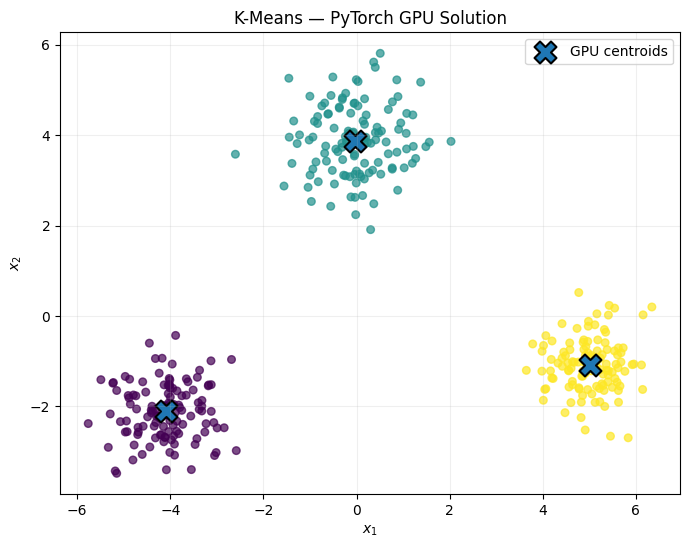

In [11]:
import matplotlib.pyplot as plt

# Bring GPU results back to CPU for Matplotlib
X_plot = X_t.detach().cpu().numpy()
labels_plot = labels_gpu.detach().cpu().numpy()
M_plot = M_gpu.detach().cpu().numpy()

plt.figure(figsize=(8, 6))

plt.scatter(
    X_plot[:, 0],
    X_plot[:, 1],
    c=labels_plot,
    s=30,
    alpha=0.7,
)

plt.scatter(
    M_plot[:, 0],
    M_plot[:, 1],
    marker="X",
    s=250,
    edgecolors="black",
    linewidths=1.5,
    label="GPU centroids",
)

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("K-Means — PyTorch GPU Solution")
plt.legend()
plt.grid(alpha=0.2)
plt.show()